# (1+1)D Viscous Burgers Equation — Three-Stage Workflow

The viscous Burgers equation is:

$$\partial_t u + u\,\partial_x u - \nu\,\partial_{xx} u = 0, \quad (x,t) \in [-1,1] \times [0,1]$$

with initial condition $u(0,x) = -\sin(\pi x)$ and homogeneous Dirichlet BCs $u(t,\pm 1) = 0$.

**Parameter:** $\nu = 0.01/\pi$ (forms a near-shock near $t \approx 0.5$).

This notebook follows a **three-stage workflow**, mirroring the Grey–Scott example:

| Stage | Description |
|-------|-------------|
| 1. **Numerical solve** | Pseudo-spectral ETD / Dopri5 reference on a fine grid |
| 2. **Data-driven fit** | Pure regression from 10 000 noisy sensor readings |
| 3. **PINN refinement** | Warm-start from Stage 2 weights; add PDE + IC loss |


In [1]:
import pinns

import numpy as np
import matplotlib.pyplot as plt

# Define the Problem

In this section, we set up all the components needed to define our PINN problem:
1. Physical parameters (viscosity)
2. The differential equation (residual form)
3. The computational domain
4. Initial and boundary conditions

## Domain of the Problem

We define the (1+1)D space-time domain $\Omega = [0, 1] \times [-1, 1]$ for $(t, x)$.

In [2]:
# Viscosity coefficient
nu = 0.01 / np.pi

domain = pinns.DomainCubic(
    space=[(-1, 1)],  # x_min, x_max
    time=[0, 1],   # t_min, t_max
)

## Differential Equation

### The PDE Residual
The `burgers_residual` function computes the residual of the viscous Burgers equation. For PINNs, we train the network to minimize this residual:

$$\mathcal{R} = \partial_t u + u \partial_x u - \nu \partial_{xx} u = 0$$

where $\nu = 0.01/\pi$ is the viscosity coefficient.

In [3]:
problem = pinns.ProblemStrong(
    domain,
    output_names=["u"]
)

problem.add_parameter('nu', 0.01 / np.pi)

ProblemStrong(domain=DomainCubic, n_dims=2, n_outputs=1, inner=0, boundary=0, initial=0, params=['nu'], trainable=[])

In [4]:
import jax.numpy as jnp

def burgers_residual(X, U, params, derivative=None):
    # X columns: 0=x, 1=t
    nu = params['parameter']['nu']

    u_t  = derivative.all(X, (1,))      # ∂u/∂t   (N, 1)
    u_x  = derivative.all(X, (0,))      # ∂u/∂x   (N, 1)
    u_xx = derivative.all(X, (0, 0))    # ∂²u/∂x² (N, 1)

    return u_t + U * u_x - nu * u_xx   # (N, 1)

problem.add_inner(burgers_residual, name="pde")


ProblemStrong(domain=DomainCubic, n_dims=2, n_outputs=1, inner=1, boundary=0, initial=0, params=['nu'], trainable=[])

## Initial and Boundary Conditions

For the viscous Burgers problem, we have:

**Initial condition** at $t = 0$:
$$u(0, x) = -\sin(\pi x), \quad \text{for } x \in [-1, 1]$$

**Boundary conditions** (homogeneous Dirichlet):
$$u(t, -1) = 0 \quad \text{and} \quad u(t, 1) = 0, \quad \text{for } t \in [0, 1]$$

In [5]:
import jax.numpy as jnp

# Initial condition: u(0, x) = -sin(πx)
def initial_condition(X):
    x = X[:, 0:1]  # First column is x
    return -jnp.sin(jnp.pi * x)

problem.add_initial(
    initial_condition,
    name="initial",
)

# Boundary conditions: u(t, -1) = 0 and u(t, 1) = 0
problem.add_boundary(
    0.0,
    region="xmin",
    name="xmin",
)
problem.add_boundary(
    0.0,
    region="xmax",
    name="xmax",
)


ProblemStrong(domain=DomainCubic, n_dims=2, n_outputs=1, inner=1, boundary=2, initial=1, params=['nu'], trainable=[])

## Reference Solution (pseudo-spectral adaptive Dopri5)

A high-accuracy reference is computed using `ModelSolver` + `IntegratorDopri5`
(native adaptive Dormand-Prince 4(5)) on a **DST-1 spectral grid** with homogeneous Dirichlet BCs.

$$\partial_t \hat{u}_k = \underbrace{-\nu k^2 \hat{u}_k}_{\text{linear (exact)}} + \underbrace{\widehat{(-u \partial_x u)}}_{\text{nonlinear (physical-space FD)}}$$

`bc="dirichlet"` uses the Discrete Sine Transform — interior nodes only, zero BCs
at $x = \pm 1$ are implicit in the basis.  The nonlinear term $-u \partial_x u$ is
evaluated in physical space using second-order central differences (matching the
previous `scipy` approach), then transformed back to spectral space.


Text(0.5, 1.0, 'Reference solution u(t,x)')

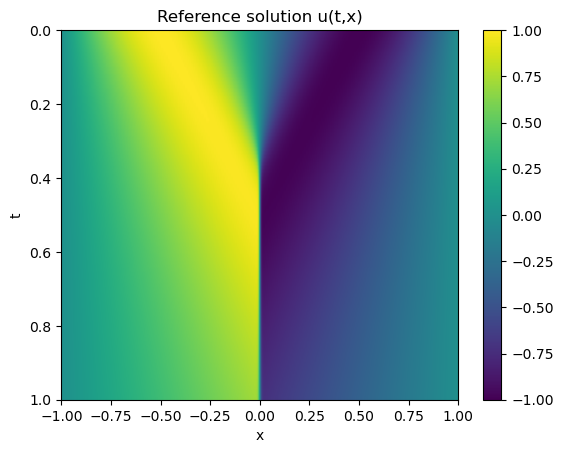

In [6]:
# ── Parameters ────────────────────────────────────────────────────────────────
Nx  = 512   # interior grid points
Nt  = 200

# ── DomainCubic + ModelSpectralSolver ─────────────────────────────────────────
domain_grid = pinns.DomainCubic(
    space=[(-1.0, 1.0)],
    time=(0.0, 1.0),
)

integrator_ref = pinns.AdaptiveIntegrator(
    pinns.IntegratorDopri5(),
    dt0=1e-2,
    max_steps=2**12,
)

model_burgers = pinns.ModelSpectralSolver(domain_grid, ["u"], integrator_ref, shape=(Nx,))

# Grid nodes are exposed by ModelSpectralSolver after construction
x_ref = np.array(model_burgers.x)   # (Nx,) interior nodes
dx    = float(x_ref[1] - x_ref[0])

# ── Linear operator: ν ∂²_x  →  −ν k² in spectral space ─────────────────────
model_burgers.set_linear_op(
    lambda X, p: {"u": -p["parameter"]["nu"] * X**2}
)

# ── Nonlinear operator: −u ∂_x u (central FD in physical space) ──────────────
def burgers_nonlinear(X, U, p):
    u     = model_burgers.inverse(U["u"])                       # (Nx,) interior
    u_ext = jnp.concatenate([jnp.zeros(1), u, jnp.zeros(1)])   # ghost BCs
    u_x   = (u_ext[2:] - u_ext[:-2]) / (2.0 * dx)             # central diff ∂_x u
    return {"u": model_burgers.forward(-u * u_x)}

model_burgers.set_source_fn(burgers_nonlinear)
model_burgers.add_parameter("nu", nu)

# ── Initial condition: u(x, 0) = −sin(πx) ────────────────────────────────────
model_burgers.add_initial(-jnp.sin(jnp.pi * jnp.array(x_ref)))

# ── Forward solve — runs once, caches interpolants ────────────────────────────
U_sol  = model_burgers.solve()
U_ref  = np.array(U_sol["u"])   # (Nt, Nx) for plotting

# ── Reference callable: predict(X) interpolates without re-solving ────────────
u_reference = model_burgers.predict   # function, not array

# ── Quick plot ────────────────────────────────────────────────────────────────
plt.imshow(U_ref, extent=(-1, 1, 1, 0), aspect='auto', cmap='viridis')
plt.colorbar(); plt.xlabel("x"); plt.ylabel("t"); plt.title("Reference solution u(t,x)")


## Stage 2 — Data-Driven Fitting (no physics)

We sample **10 000 scattered points** $(x_i, t_i)$ uniformly from the
space–time domain, read off the reference values $u_i$, and add **1 % Gaussian noise**.

A Fourier-feature network is trained purely from data — no PDE or IC loss is imposed.
This produces a smooth, low-error warm-start for Stage 3.

The network architecture is:

$$\text{Input: }(x,t) \xrightarrow{\text{Normalize}} \text{RFF}(128,\,\sigma=2) \rightarrow \text{FNN}[256,256,256] \xrightarrow{\tanh} u$$


In [22]:
# ── Sample 10 000 scattered (x, t) points ────────────────────────────────────
rng = np.random.default_rng(42)
N_data = 10_000

x_samp = rng.uniform(-1.0, 1.0, N_data)
t_samp = rng.uniform( 0.0, 1.0, N_data)
X_data = np.stack([x_samp, t_samp], axis=1)   # (N_data, 2)  col 0=x, col 1=t

U_data = model_burgers.predict(X_data) + np.random.normal(0, 0.05, size=(N_data, 1))  # (N_data, 1) numpy

# ── Create dataset ────────────────────────────────────
dataset = pinns.Dataset()
dataset.add_points(X_data, U_data, name="data", component=0)


Dataset(1 term(s)){
  'data': 10000 pts, comp=[0]
}

In [23]:
# ── Fourier-feature network ───────────────────────────────────────────────────
# Input: (x, t) — 2 dims.  Output: u — 1 dim.
# RFF σ=2 captures the sharp near-shock profile (O(10) cycles / unit length).
net = pinns.create_model(
    domain,
    output_dim=1,
    features=pinns.FourierFeatures(n_features=128, sigma=2.0),
    core=pinns.FNN([256, 256, 256], activation="tanh"),
    normalize=True,
)
print(net)


ModelBase(output_dim=1)
  [Normalize_0] Normalize(n_coord=2, n_context=0, context_scaled=False)
  [RandomFourierFeatures_1] RandomFourierFeatures(fourier_input_dim=2, n_features=128, sigma=2.0, adaptive=True)
  [FNN_2] FNN(layer_sizes=[256, 256, 256, 256, 1])


Starting training for 20000 epochs (JIT-compiled)...


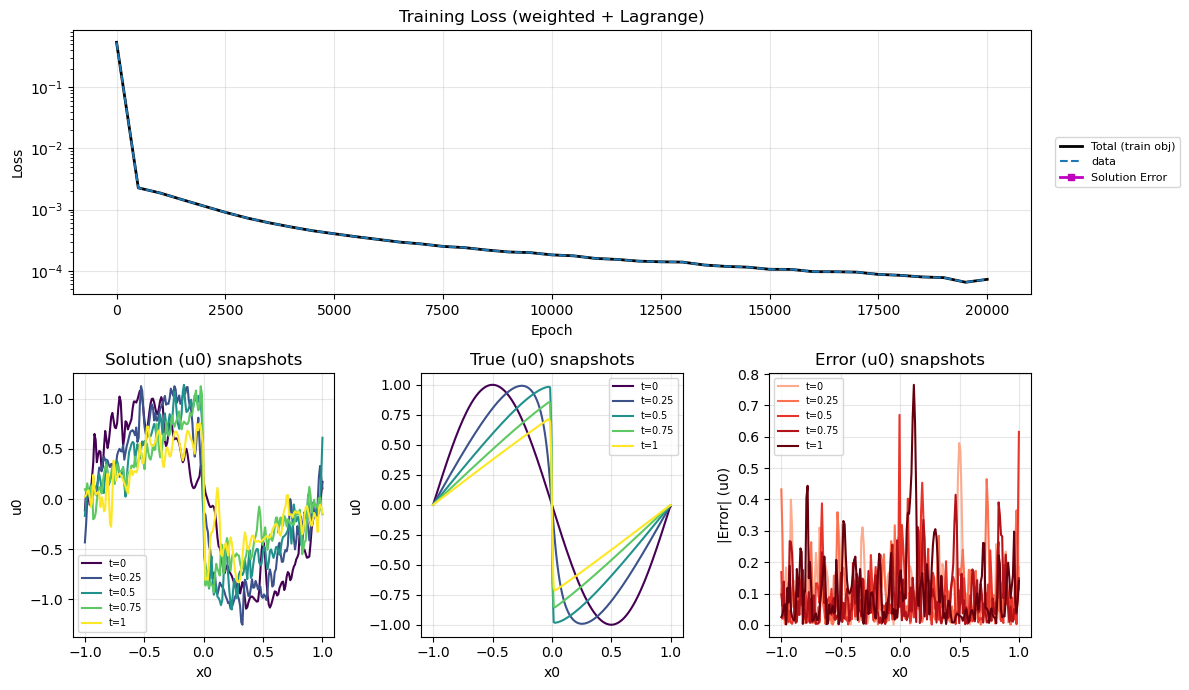

Epoch 0/20000 | Loss: 5.42e-01 | MSE: 5.42e-01 | Terms: [] | Data: [data: 5.42e-01] | Error: N/A | Time: 0.0s
Epoch 500/20000 | Loss: 2.27e-03 | MSE: 2.27e-03 | Terms: [] | Data: [data: 2.27e-03] | Error: N/A | Time: 3.1s
Epoch 1000/20000 | Loss: 1.87e-03 | MSE: 1.87e-03 | Terms: [] | Data: [data: 1.87e-03] | Error: N/A | Time: 4.3s
Epoch 1500/20000 | Loss: 1.46e-03 | MSE: 1.46e-03 | Terms: [] | Data: [data: 1.46e-03] | Error: N/A | Time: 5.4s
Epoch 2000/20000 | Loss: 1.14e-03 | MSE: 1.14e-03 | Terms: [] | Data: [data: 1.14e-03] | Error: N/A | Time: 6.6s
Epoch 2500/20000 | Loss: 9.02e-04 | MSE: 9.02e-04 | Terms: [] | Data: [data: 9.02e-04] | Error: N/A | Time: 7.8s
Epoch 3000/20000 | Loss: 7.27e-04 | MSE: 7.27e-04 | Terms: [] | Data: [data: 7.27e-04] | Error: N/A | Time: 9.0s
Epoch 3500/20000 | Loss: 6.08e-04 | MSE: 6.08e-04 | Terms: [] | Data: [data: 6.08e-04] | Error: N/A | Time: 10.2s
Epoch 4000/20000 | Loss: 5.20e-04 | MSE: 5.20e-04 | Terms: [] | Data: [data: 5.20e-04] | Error: N/A

In [ ]:
# ── Data-only training ────────────────────────────────────────────────────────
trainer = pinns.Trainer(net, problem=None, dataset=dataset)
trainer.set_solution(model_burgers.predict)

trainer.compile(
    dataset={
        "data": {"train": 2000, "test": 200, "weight": 1.0},
    },
    optimizer=pinns.SOAPOptimizer(),
    schedulers=[pinns.SchedulerResample(1)],
    epochs=20000,
    print_each=500,
    show=pinns.TrainPlotter(time_points=[0.0, 0.25, 0.5, 0.75, 1.0]),
)

trainer.train()

## Stage 3 — PINN Fine-Tuning (warm start from data weights)

The data-trained network already fits the smooth structure of the solution.
We now **fine-tune with physics**, adding:

* **PDE residual** $\mathcal{R} = u_t + u\,u_x - \nu\,u_{xx}$ in the interior
* **Initial condition** $u(0,x) = -\sin(\pi x)$
* **Boundary conditions** $u(t,\pm 1) = 0$
* **Data** terms at a reduced weight so the PDE gradually takes over

The pretrained weights are restored explicitly because `Trainer.__init__` resets
`model.params`, so we save and inject them manually.


Starting training for 50000 epochs (JIT-compiled)...


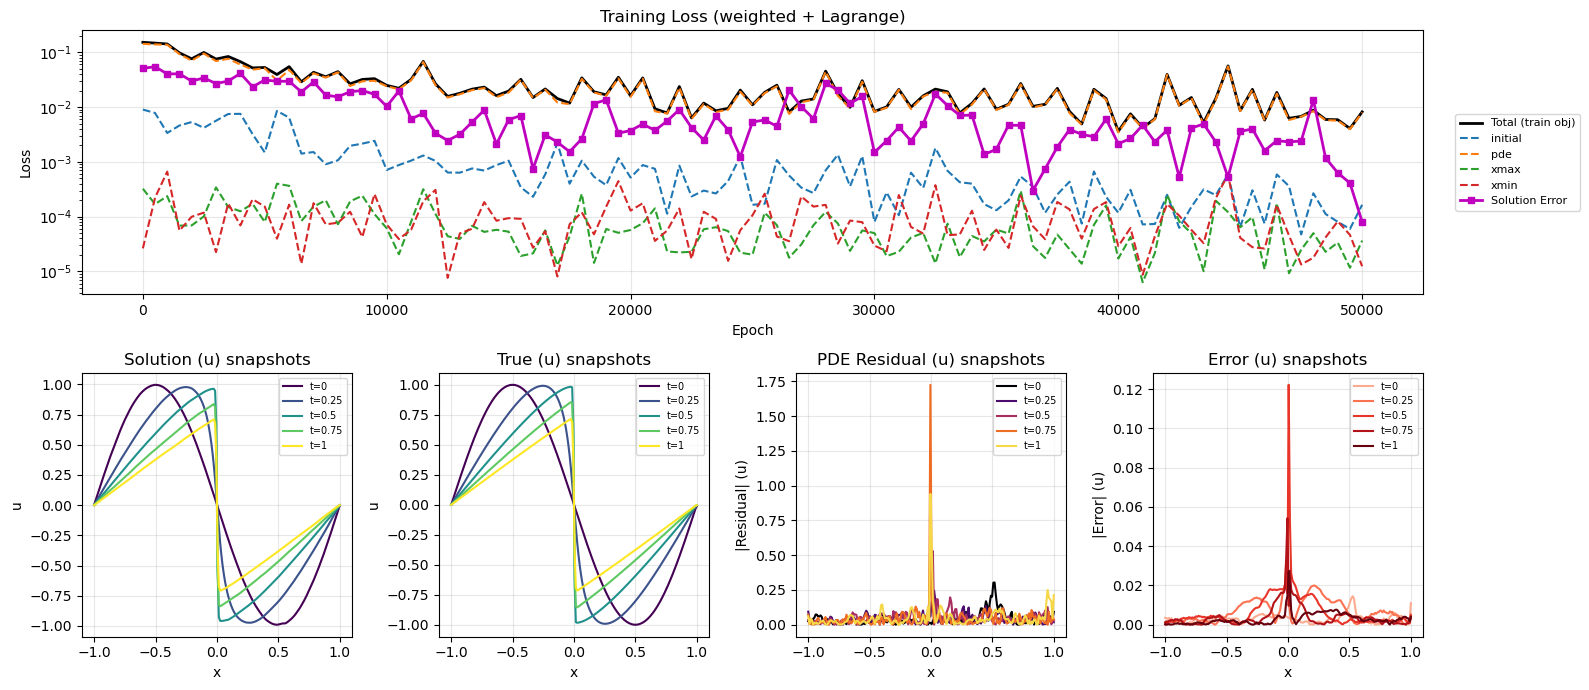

Epoch 0/50000 | Loss: 1.52e-01 | MSE: 1.43e-01 | Terms: [initial: 9.01e-04, pde: 1.43e-01, xmax: 3.24e-05, xmin: 2.64e-06] | Error: 5.08e-02 | Time: 0.0s
Epoch 500/50000 | Loss: 1.47e-01 | MSE: 1.40e-01 | Terms: [initial: 7.81e-04, pde: 1.39e-01, xmax: 1.70e-05, xmin: 2.22e-05] | Error: 5.46e-02 | Time: 4.0s
Epoch 1000/50000 | Loss: 1.42e-01 | MSE: 1.38e-01 | Terms: [initial: 3.37e-04, pde: 1.37e-01, xmax: 2.37e-05, xmin: 6.64e-05] | Error: 4.02e-02 | Time: 5.5s
Epoch 1500/50000 | Loss: 9.76e-02 | MSE: 9.34e-02 | Terms: [initial: 4.61e-04, pde: 9.29e-02, xmax: 6.87e-06, xmin: 5.57e-06] | Error: 4.05e-02 | Time: 7.2s
Epoch 2000/50000 | Loss: 7.60e-02 | MSE: 7.10e-02 | Terms: [initial: 5.33e-04, pde: 7.05e-02, xmax: 6.92e-06, xmin: 9.96e-06] | Error: 2.98e-02 | Time: 8.6s
Epoch 2500/50000 | Loss: 9.93e-02 | MSE: 9.53e-02 | Terms: [initial: 4.18e-04, pde: 9.49e-02, xmax: 1.01e-05, xmin: 1.19e-05] | Error: 3.40e-02 | Time: 10.1s
Epoch 3000/50000 | Loss: 7.52e-02 | MSE: 6.98e-02 | Terms: [i

In [ ]:
# ── PINN trainer (warm-started from data-fitting weights) ─────────────────────
# Trainer.__init__ resets model.params, so save and restore manually.
pretrained_params = trainer.model.params

pinn_trainer = pinns.Trainer(net, problem=problem, dataset=None)
pinn_trainer.model.params = pretrained_params

pinn_trainer.set_solution(u_reference)

pinn_trainer.compile(
    problem={
        "pde":     {"n_points": 3000, "weight": 1.0},
        "initial": {"n_points": 500,  "weight": 10.0},
        "xmin":    {"n_points": 200,  "weight": 10.0},
        "xmax":    {"n_points": 200,  "weight": 10.0},
    },
    dataset={
        "data": {"train": 2000, "test": 200, "weight": 0.1},
    },
    optimizer=pinns.AdamOptimizer(learning_rate=1e-4),
    schedulers=[
        pinns.SchedulerResample(1),
        pinns.SchedulerCausal(),
    ],
    epochs=50000,
    print_each=500,
    show=pinns.TrainPlotter(time_points=[0.0, 0.25, 0.5, 0.75, 1.0]),
)

pinn_trainer.train()